# Nuclear Waste Canister Temperature Prediction — Neural Network
**CIVIL-226 - Introduction to Machine Learning for Engineers — EPFL**  
**Team name:** [To fill]  
**Members:** [To fill]

## Objective
Predict the temperature around nuclear waste canisters at unobserved sensor positions,
using heating power, time, spatial coordinates, and cumulative energy.

This notebook implements a deep neural network trained with AdamW optimizer and Huber loss,
with a sensor-based train/validation split to better estimate generalization performance.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import torch
import torchvision
import pandas as pd
import numpy as np
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
train = pd.read_parquet("train.parquet")
test = pd.read_parquet("test.parquet")
sensors = pd.read_parquet("sensors.parquet")

## Merge sensor positions into train data

In [3]:
train_full = train.merge(sensors, on="sensor", how="left")
print(train_full.head())
print(train_full.shape)

  sensor       time        power  temperature     coor_x  coor_y  coor_z
0   N102        0.0  1487.964722    17.514429  46.131474     3.5     0.0
1   N102   864000.0  1487.288818    17.820795  46.131474     3.5     0.0
2   N102  1728000.0  1486.612915    17.573187  46.131474     3.5     0.0
3   N102  2592000.0  1485.936890    16.513235  46.131474     3.5     0.0
4   N102  3456000.0  1485.260986    16.303427  46.131474     3.5     0.0
(6626928, 7)


## Clean missing values

In [4]:
train_full = train_full.dropna()
print(train_full.shape)
print(train_full.columns)

(6527525, 7)
Index(['sensor', 'time', 'power', 'temperature', 'coor_x', 'coor_y', 'coor_z'], dtype='str')


## Data exploration

Temperature min: -292.15085
Temperature max: 6039.05

Power min: 0.0
Power max: 1500.0

Time min: 0.0
Time max: 7884000000.0


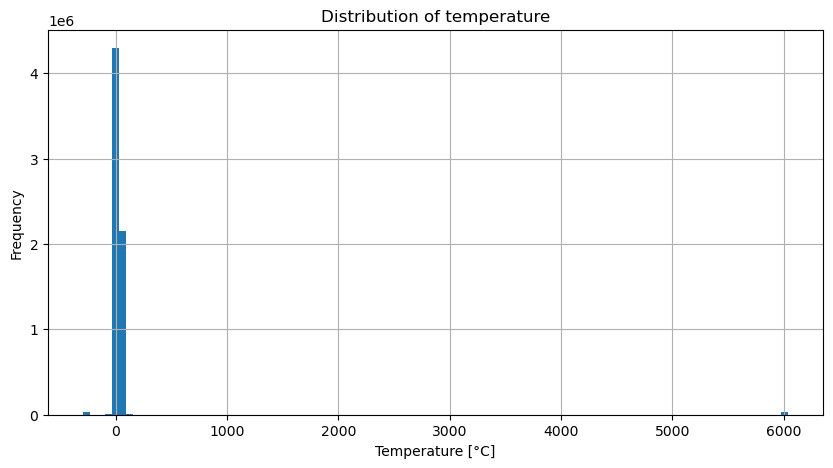

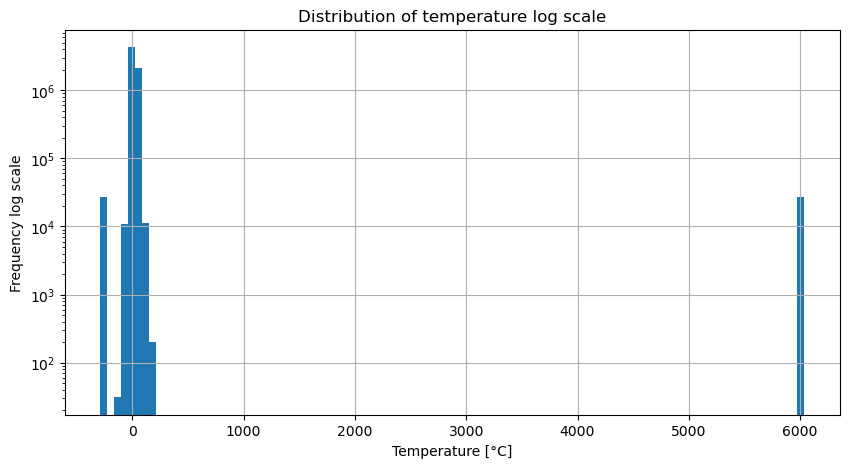

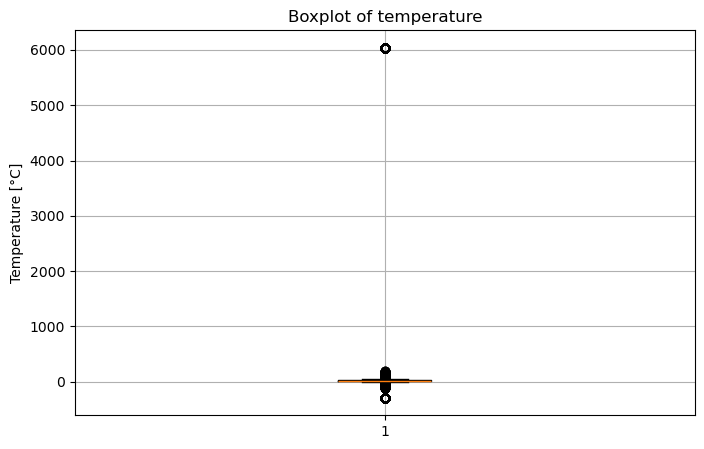

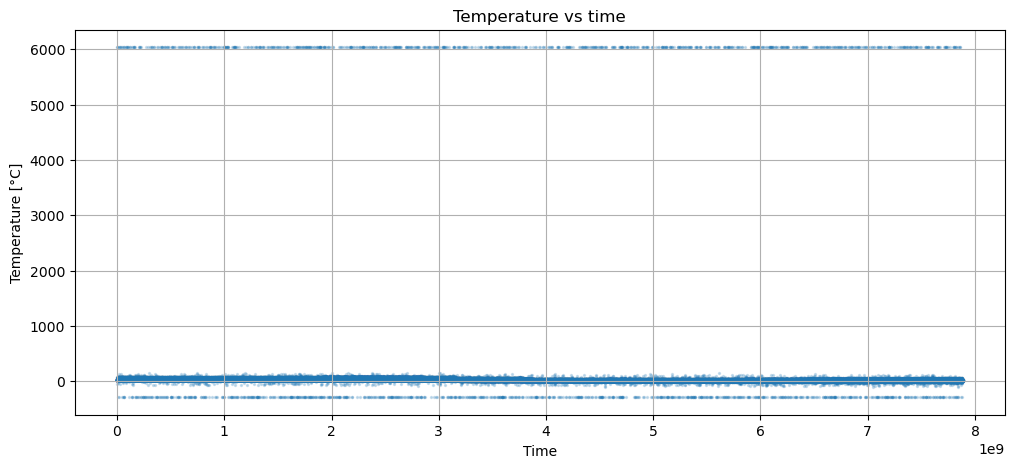

In [5]:
train_full["temperature"].describe(percentiles=[
    0.001, 0.005, 0.01, 0.05,
    0.25, 0.5, 0.75,
    0.95, 0.99, 0.995, 0.999
])
print("Temperature min:", train_full["temperature"].min())
print("Temperature max:", train_full["temperature"].max())

print("\nPower min:", train_full["power"].min())
print("Power max:", train_full["power"].max())

print("\nTime min:", train_full["time"].min())
print("Time max:", train_full["time"].max())
import matplotlib.pyplot as plt

# Histogram (frequency_temperature)
plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency")
plt.title("Distribution of temperature")
plt.grid(True)
plt.show()

# Histogram (log frequency_temperature)
plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.yscale("log")
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency log scale")
plt.title("Distribution of temperature log scale")
plt.grid(True)
plt.show()

# Box plot
plt.figure(figsize=(8, 5))
plt.boxplot(train_full["temperature"], vert=True, showfliers=True)
plt.ylabel("Temperature [°C]")
plt.title("Boxplot of temperature")
plt.grid(True)
plt.show()

# Temperature_Time
sample_df = train_full.sample(n=200_000, random_state=42)

plt.figure(figsize=(12, 5))
plt.scatter(
    sample_df["time"],
    sample_df["temperature"],
    s=2,
    alpha=0.2
)
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.title("Temperature vs time")
plt.grid(True)
plt.show()

## Remove outliers and sensor drift

Diagnostica iniziale (skippabile)

In [6]:
# ============================================================
# Diagnostics: outliers, failed sensors, possible drift
# ============================================================

print("Dataset shape:", train_full.shape)
print("Numero sensori:", train_full["sensor"].nunique())

print("\nTemperature summary:")
display(train_full["temperature"].describe(percentiles=[
    0.001, 0.005, 0.01, 0.05,
    0.25, 0.5, 0.75,
    0.95, 0.99, 0.995, 0.999
]))

sensor_stats = (
    train_full
    .groupby("sensor")
    .agg(
        n_obs=("temperature", "size"),
        n_missing=("temperature", lambda x: x.isna().sum()),
        temp_mean=("temperature", "mean"),
        temp_std=("temperature", "std"),
        temp_min=("temperature", "min"),
        temp_max=("temperature", "max"),
        time_min=("time", "min"),
        time_max=("time", "max"),
        coor_x=("coor_x", "first"),
        coor_y=("coor_y", "first")
    )
    .reset_index()
)

sensor_stats["missing_rate"] = sensor_stats["n_missing"] / sensor_stats["n_obs"]
sensor_stats["time_span"] = sensor_stats["time_max"] - sensor_stats["time_min"]

display(sensor_stats.sort_values("temp_std").head(20))
display(sensor_stats.sort_values("temp_std", ascending=False).head(20))

Dataset shape: (6527525, 7)
Numero sensori: 242

Temperature summary:


count    6.527525e+06
mean     4.706069e+01
std      3.897674e+02
min     -2.921508e+02
0.1%    -2.921508e+02
0.5%    -6.022708e+01
1%      -1.495938e+01
5%       3.050485e+00
25%      1.566275e+01
50%      1.939439e+01
75%      2.877052e+01
95%      5.601719e+01
99%      7.570076e+01
99.5%    1.047497e+02
99.9%    6.039050e+03
max      6.039050e+03
Name: temperature, dtype: float64

,sensor,n_obs,n_missing,temp_mean,temp_std,temp_min,temp_max,time_min,time_max,coor_x,coor_y,missing_rate,time_span
53,N277,27384,0,-292.150848,0.000000,-292.150848,-292.150848,0.0,7.884000e+09,5.590834,1.750000,0.0,7.884000e+09
239,N927,27384,0,6039.049805,0.000000,6039.049805,6039.049805,0.0,7.884000e+09,1.182325,3.283760,0.0,7.884000e+09
60,N3,26969,0,17.000349,0.501007,14.881579,19.118944,0.0,7.884000e+09,50.000000,0.000000,0.0,7.884000e+09
241,N96,26953,0,16.997625,0.501199,14.956888,19.138594,0.0,7.884000e+09,50.000000,0.875000,0.0,7.884000e+09
149,N674,26981,0,17.045420,0.507032,14.631433,19.274443,0.0,7.884000e+09,49.230309,1.761023,0.0,7.884000e+09
0,N102,26965,0,17.238297,0.618805,15.090989,19.901480,0.0,7.884000e+09,46.131474,3.500000,0.0,7.884000e+09
168,N745,26994,0,17.272451,0.652538,14.654485,19.886028,0.0,7.884000e+09,45.606064,1.752127,0.0,7.884000e+09
153,N689,26961,0,17.497511,0.919088,14.742880,20.917267,0.0,7.884000e+09,42.224983,1.750000,0.0,7.884000e+09
162,N723,26971,0,17.554255,0.998518,14.623532,20.787815,0.0,7.884000e+09,41.395592,2.820246,0.0,7.884000e+09
195,N838,26989,0,18.725485,1.081293,15.267212,21.911045,0.0,7.884000e+09,49.512234,3.048786,0.0,7.884000e+09


,sensor,n_obs,n_missing,temp_mean,temp_std,temp_min,temp_max,time_min,time_max,coor_x,coor_y,missing_rate,time_span
231,N918,26978,0,9.294864,30.359613,-33.844723,60.355274,0.0,7.884000e+09,0.358713,3.314945,0.0,7.884000e+09
25,N200,26953,0,30.164801,29.033003,-97.490067,179.888260,0.0,7.884000e+09,0.500000,1.500000,0.0,7.884000e+09
26,N201,26954,0,30.153286,28.989992,-99.214371,175.821671,0.0,7.884000e+09,0.500000,1.800000,0.0,7.884000e+09
128,N6,26943,0,30.009701,28.969713,-99.829506,178.348999,0.0,7.884000e+09,0.000000,2.400000,0.0,7.884000e+09
101,N5,26966,0,30.170284,28.944794,-99.559898,173.701843,0.0,7.884000e+09,0.500000,2.400000,0.0,7.884000e+09
27,N202,26971,0,30.132093,28.924698,-100.193153,171.754608,0.0,7.884000e+09,0.500000,2.100000,0.0,7.884000e+09
24,N197,26999,0,30.169241,28.909618,-98.977097,171.470490,0.0,7.884000e+09,0.500000,0.600000,0.0,7.884000e+09
28,N203,26983,0,30.164686,28.864246,-97.795731,174.556686,0.0,7.884000e+09,0.250000,2.400000,0.0,7.884000e+09
29,N204,26991,0,11.451667,28.371035,-119.050781,153.614197,0.0,7.884000e+09,1.400000,0.291667,0.0,7.884000e+09
230,N917,27021,0,29.082800,26.413229,-97.562920,167.852036,0.0,7.884000e+09,0.701819,0.766279,0.0,7.884000e+09


Identificazione outliers globali con metodo robusto MAD

In [7]:
# ============================================================
# Identify global temperature outliers using MAD
# ============================================================

temp = train_full["temperature"]

median_temp = temp.median()
mad_temp = np.median(np.abs(temp - median_temp))

robust_z = 0.6745 * (temp - median_temp) / (mad_temp + 1e-8)

train_full["temperature_robust_z"] = robust_z
train_full["is_global_outlier"] = train_full["temperature_robust_z"].abs() > 6

print("Global temperature median:", median_temp)
print("Global temperature MAD:", mad_temp)
print("Numero global outliers:", train_full["is_global_outlier"].sum())

display(
    train_full.loc[
        train_full["is_global_outlier"],
        ["sensor", "time", "temperature", "temperature_robust_z", "coor_x", "coor_y"]
    ].sort_values("temperature_robust_z", key=np.abs, ascending=False).head(30)
)

Global temperature median: 19.394394
Global temperature MAD: 6.2745953
Numero global outliers: 114636


,sensor,time,temperature,temperature_robust_z,coor_x,coor_y
4390568,N927,0.000000e+00,6039.049805,647.094727,1.182325,3.28376
4390569,N927,8.640000e+05,6039.049805,647.094727,1.182325,3.28376
4390570,N927,1.728000e+06,6039.049805,647.094727,1.182325,3.28376
4390571,N927,2.592000e+06,6039.049805,647.094727,1.182325,3.28376
4390572,N927,3.456000e+06,6039.049805,647.094727,1.182325,3.28376
4390573,N927,4.320000e+06,6039.049805,647.094727,1.182325,3.28376
4390574,N927,5.184000e+06,6039.049805,647.094727,1.182325,3.28376
4390575,N927,6.048000e+06,6039.049805,647.094727,1.182325,3.28376
4390576,N927,6.912000e+06,6039.049805,647.094727,1.182325,3.28376
4390577,N927,7.776000e+06,6039.049805,647.094727,1.182325,3.28376


Identificazione outliers locali per time step

In [8]:
# ============================================================
# Identify local outliers by time step
# ============================================================

time_stats = (
    train_full
    .groupby("time")["temperature"]
    .agg(
        time_median="median",
        time_q1=lambda x: x.quantile(0.25),
        time_q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

time_stats["time_iqr"] = time_stats["time_q3"] - time_stats["time_q1"]

train_full = train_full.merge(time_stats, on="time", how="left")

train_full["local_outlier_low"] = (
    train_full["temperature"] <
    train_full["time_median"] - 4.0 * train_full["time_iqr"]
)

train_full["local_outlier_high"] = (
    train_full["temperature"] >
    train_full["time_median"] + 4.0 * train_full["time_iqr"]
)

train_full["is_local_outlier"] = (
    train_full["local_outlier_low"] | train_full["local_outlier_high"]
)

print("Numero local outliers:", train_full["is_local_outlier"].sum())

display(
    train_full.loc[
        train_full["is_local_outlier"],
        ["sensor", "time", "temperature", "time_median", "time_iqr", "coor_x", "coor_y"]
    ].head(30)
)

Numero local outliers: 106226


,sensor,time,temperature,time_median,time_iqr,coor_x,coor_y
9035,N103,2.851200e+07,-47.918625,18.181341,9.751772,45.198502,3.5
9443,N103,3.879360e+08,-54.551613,23.868603,19.564972,45.198502,3.5
9528,N103,4.631040e+08,-56.190224,24.357656,19.696112,45.198502,3.5
10000,N103,8.839584e+08,-59.276253,25.205601,18.312126,45.198502,3.5
10216,N103,1.073174e+09,-69.667572,29.960182,20.507034,45.198502,3.5
10687,N103,1.486166e+09,115.765007,30.370043,17.612062,45.198502,3.5
10866,N103,1.645229e+09,-44.676342,29.963100,16.510450,45.198502,3.5
12096,N103,2.721859e+09,-71.627731,29.264856,23.703188,45.198502,3.5
12301,N103,2.899843e+09,-79.899612,28.867897,20.558207,45.198502,3.5
12449,N103,3.031171e+09,108.993118,27.974300,19.135895,45.198502,3.5


Rimozione outliers

In [9]:
# ============================================================
# Remove outliers from training data
# ============================================================

before_rows = len(train_full)

train_full = train_full[
    (~train_full["is_global_outlier"]) &
    (~train_full["is_local_outlier"])
].copy()

after_rows = len(train_full)

print(f"Rows before outlier removal : {before_rows}")
print(f"Rows after outlier removal  : {after_rows}")
print(f"Removed rows                : {before_rows - after_rows}")

# Rimuovo colonne temporanee di diagnostica
cols_to_drop = [
    "temperature_robust_z",
    "is_global_outlier",
    "time_median",
    "time_q1",
    "time_q3",
    "time_iqr",
    "local_outlier_low",
    "local_outlier_high",
    "is_local_outlier"
]

train_full = train_full.drop(columns=[c for c in cols_to_drop if c in train_full.columns])

Rows before outlier removal : 6527525
Rows after outlier removal  : 6382332
Removed rows                : 145193


Identificazione sensor drift

In [10]:
# ============================================================
# Identify sensor drift
# ============================================================

# Mediana globale per ogni istante temporale
time_median = (
    train_full
    .groupby("time")["temperature"]
    .median()
    .rename("global_time_median")
    .reset_index()
)

drift_df = train_full.merge(time_median, on="time", how="left").copy()

# Residuo del sensore rispetto al comportamento medio dello stesso istante
drift_df["temp_residual"] = drift_df["temperature"] - drift_df["global_time_median"]

# Tempo normalizzato solo per stimare slope in modo stabile
t_min = drift_df["time"].min()
t_max = drift_df["time"].max()
drift_df["time_norm_for_drift"] = (drift_df["time"] - t_min) / (t_max - t_min + 1e-8)

drift_records = []

for sensor_id, g in drift_df.groupby("sensor"):
    g = g.sort_values("time_norm_for_drift")

    if len(g) < 20:
        continue

    x = g["time_norm_for_drift"].values
    y = g["temp_residual"].values

    if np.std(y) < 1e-8:
        slope = 0.0
        corr = 0.0
    else:
        slope = np.polyfit(x, y, 1)[0]
        corr = np.corrcoef(x, y)[0, 1]

    drift_records.append({
        "sensor": sensor_id,
        "n_obs": len(g),
        "drift_slope": slope,
        "drift_corr": corr,
        "residual_std": np.std(y),
        "residual_mean": np.mean(y),
        "coor_x": g["coor_x"].iloc[0],
        "coor_y": g["coor_y"].iloc[0],
    })

sensor_drift = pd.DataFrame(drift_records)

# Soglie robuste
slope_abs = sensor_drift["drift_slope"].abs()
slope_threshold = slope_abs.median() + 4 * (np.median(np.abs(slope_abs - slope_abs.median())) + 1e-8)

sensor_drift["is_drift_sensor"] = (
    (sensor_drift["drift_slope"].abs() > slope_threshold) &
    (sensor_drift["drift_corr"].abs() > 0.5)
)

drift_sensors = sensor_drift.loc[sensor_drift["is_drift_sensor"], "sensor"].unique()

print("Slope threshold:", slope_threshold)
print("Numero sensori con possibile drift:", len(drift_sensors))

display(
    sensor_drift
    .sort_values("drift_slope", key=np.abs, ascending=False)
    .head(30)
)

Slope threshold: 53.42568040482184
Numero sensori con possibile drift: 2


,sensor,n_obs,drift_slope,drift_corr,residual_std,residual_mean,coor_x,coor_y,is_drift_sensor
230,N918,19352,-66.660702,-0.786676,21.603182,-1.200771,0.358713,3.314945,True
29,N204,22852,-65.348535,-0.812002,21.551580,-5.375889,1.400000,0.291667,True
234,N923,26919,-52.775436,-0.769401,19.752274,-0.495558,1.189514,0.766669,False
225,N910,26513,-49.269892,-0.682221,20.810301,7.179052,0.234196,2.636769,False
229,N917,26331,-49.156034,-0.685152,20.727306,6.941002,0.701819,0.766279,False
232,N921,26547,-49.120047,-0.681644,20.759422,7.240829,0.727319,0.231088,False
22,N188,26591,-49.024458,-0.678675,20.792839,7.269429,0.000000,2.675000,False
226,N912,26689,-48.983668,-0.679935,20.727480,7.315079,0.710749,1.953373,False
231,N920,26875,-48.649061,-0.684626,20.431606,7.296055,0.475365,2.618823,False
224,N909,26727,-47.913364,-0.678852,20.295050,7.208868,0.780347,0.500008,False


Correzione del sensor drift nel training

In [11]:
# ============================================================
# Correct sensor drift in training data
# ============================================================

train_full = train_full.copy()

# Ricreo tempo normalizzato per applicare la correzione
t_min = train_full["time"].min()
t_max = train_full["time"].max()
train_full["time_norm_for_drift"] = (train_full["time"] - t_min) / (t_max - t_min + 1e-8)

drift_map = sensor_drift.set_index("sensor")["drift_slope"].to_dict()

train_full["drift_correction"] = 0.0

for s in drift_sensors:
    slope = drift_map[s]

    mask = train_full["sensor"] == s

    # Correzione centrata: non cambia la media del sensore, rimuove solo la deriva
    train_full.loc[mask, "drift_correction"] = (
        slope * (train_full.loc[mask, "time_norm_for_drift"] - 0.5)
    )

train_full["temperature_before_drift_correction"] = train_full["temperature"]
train_full["temperature"] = train_full["temperature"] - train_full["drift_correction"]

print("Drift correction applied.")
print("Numero righe corrette:", (train_full["drift_correction"].abs() > 0).sum())

display(
    train_full.loc[
        train_full["drift_correction"].abs() > 0,
        [
            "sensor",
            "time",
            "temperature_before_drift_correction",
            "temperature",
            "drift_correction"
        ]
    ].head(30)
)

# Colonne temporanee da rimuovere prima del training
train_full = train_full.drop(columns=[
    "time_norm_for_drift",
    "drift_correction",
    "temperature_before_drift_correction"
])

Drift correction applied.
Numero righe corrette: 42198


,sensor,time,temperature_before_drift_correction,temperature,drift_correction
260677,N204,16416000.0,50.387741,17.849542,32.538199
260678,N204,17280000.0,50.053978,17.522940,32.531038
260679,N204,18144000.0,50.651054,18.127178,32.523876
260680,N204,19008000.0,50.386490,17.869775,32.516715
260681,N204,19872000.0,50.400551,17.890997,32.509553
260682,N204,20736000.0,51.600456,19.098064,32.502392
260683,N204,21600000.0,51.373657,18.878427,32.495230
260684,N204,22464000.0,52.140423,19.652354,32.488069
260685,N204,23328000.0,52.255356,19.774448,32.480908
260686,N204,24192000.0,51.594109,19.120363,32.473746


Controllo finale dopo cleaning

In [12]:
# ============================================================
# Final checks after cleaning
# ============================================================

print("Final train_full shape:", train_full.shape)
print("Numero sensori:", train_full["sensor"].nunique())

print("\nMissing values:")
display(train_full.isna().sum())

print("\nTemperature after cleaning:")
display(train_full["temperature"].describe(percentiles=[
    0.001, 0.005, 0.01, 0.05,
    0.25, 0.5, 0.75,
    0.95, 0.99, 0.995, 0.999
]))

assert train_full["temperature"].notna().all()
assert np.isfinite(train_full["temperature"]).all()

Final train_full shape: (6382332, 7)
Numero sensori: 240

Missing values:


sensor         0
time           0
power          0
temperature    0
coor_x         0
coor_y         0
coor_z         0
dtype: int64


Temperature after cleaning:


count    6.382332e+06
mean     2.282374e+01
std      1.407158e+01
min     -6.430037e+01
0.1%    -1.638003e+01
0.5%    -7.487483e+00
1%      -1.292706e+00
5%       3.719921e+00
25%      1.572808e+01
50%      1.931156e+01
75%      2.809069e+01
95%      5.134281e+01
99%      6.770068e+01
99.5%    7.009389e+01
99.9%    7.476208e+01
max      7.520988e+01
Name: temperature, dtype: float64

## Data exploration cleaned

Temperature min: -64.30036523388388
Temperature max: 75.20988464355469

Power min: 0.0
Power max: 1500.0

Time min: 0.0
Time max: 7884000000.0


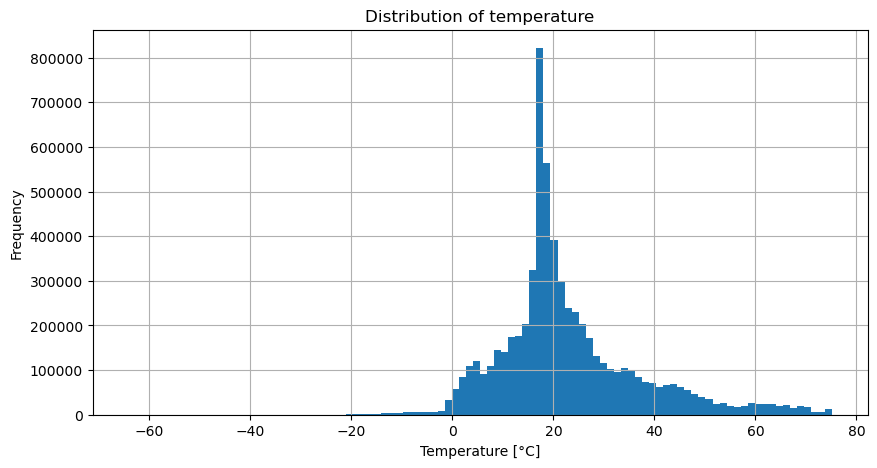

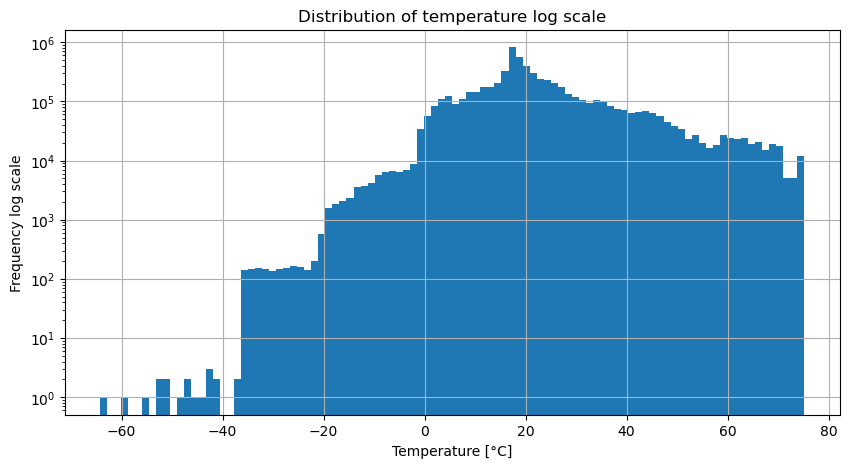

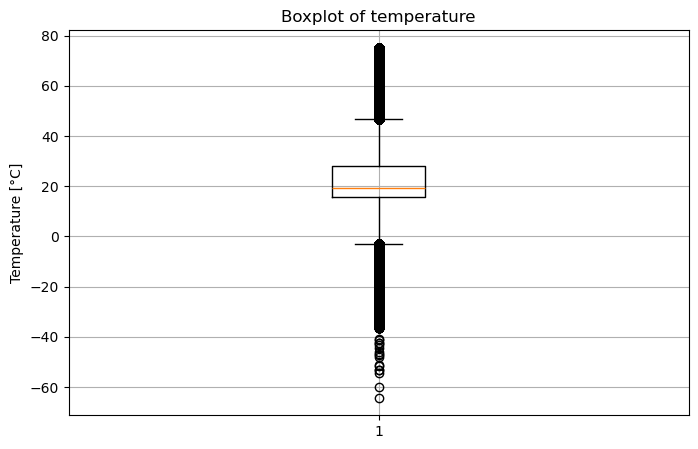

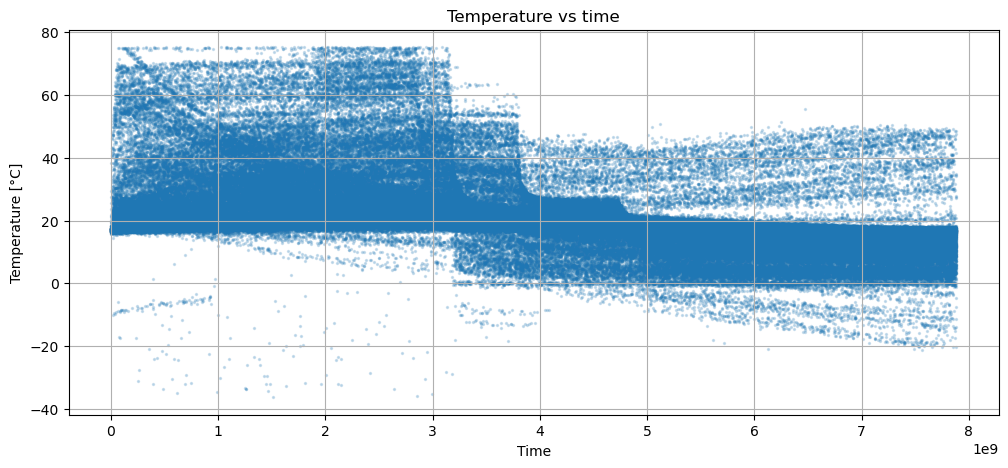

In [13]:
train_full["temperature"].describe(percentiles=[
    0.001, 0.005, 0.01, 0.05,
    0.25, 0.5, 0.75,
    0.95, 0.99, 0.995, 0.999
])
print("Temperature min:", train_full["temperature"].min())
print("Temperature max:", train_full["temperature"].max())

print("\nPower min:", train_full["power"].min())
print("Power max:", train_full["power"].max())

print("\nTime min:", train_full["time"].min())
print("Time max:", train_full["time"].max())
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency")
plt.title("Distribution of temperature")
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.yscale("log")
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency log scale")
plt.title("Distribution of temperature log scale")
plt.grid(True)
plt.show()
plt.figure(figsize=(8, 5))
plt.boxplot(train_full["temperature"], vert=True, showfliers=True)
plt.ylabel("Temperature [°C]")
plt.title("Boxplot of temperature")
plt.grid(True)
plt.show()
sample_df = train_full.sample(n=200_000, random_state=42)

plt.figure(figsize=(12, 5))
plt.scatter(
    sample_df["time"],
    sample_df["temperature"],
    s=2,
    alpha=0.2
)
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.title("Temperature vs time")
plt.grid(True)
plt.show()

## Note: this cell can be skipped

In [ ]:
train_buffer = train_full[train_full["coor_x"] < 1.4].copy()
train_opa    = train_full[train_full["coor_x"] >= 1.4].copy()
print(f'Train buffer : {train_buffer.shape}')
print(f'Train OPA    : {train_opa.shape}')


(1159166, 7)
(4958844, 7)


## Cumulative energy feature

In [15]:
# Creo una tabella temporale unica con time e power
power_time = (
    train_full[["time", "power"]]
    .drop_duplicates()
    .sort_values("time")
    .copy()
)

# Differenza temporale tra istanti successivi
power_time["dt"] = power_time["time"].diff().fillna(0)

# Energia cumulata approssimata
power_time["cum_energy"] = (power_time["power"] * power_time["dt"]).cumsum()

# Merge nel dataset principale
train_full = train_full.merge(
    power_time[["time", "cum_energy"]],
    on="time",
    how="left"
)

## Keep raw time


In [16]:
train_full = train_full.dropna(subset=["temperature"])


## Power/d2 & diffusion

In [17]:
eps = 1e-8

# Distanza quadratica dalla sorgente/origine
train_full["dist2"] = train_full["coor_x"]**2 + train_full["coor_y"]**2

# Potenza pesata per distanza quadratica
train_full["power_over_dist2"] = train_full["power"] / (train_full["dist2"] + eps)

# Feature tipo diffusione: distanza^2 / tempo
train_full["diffusion"] = train_full["dist2"] / (train_full["time"] + eps)

## Train/validation split by sensor & normalization

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

feature_cols = [
    "coor_x", "coor_y", "power", "time",
    "cum_energy", "power_over_dist2", "diffusion"
]
target_col = "temperature"

def split_and_scale(df, feature_cols, target_col, val_ratio=0.2, seed=42):
    """Split by sensor and normalize — one scaler per zone."""
    unique_sensors = df["sensor"].unique()
    rng = np.random.default_rng(seed)
    val_sensors   = rng.choice(unique_sensors, size=int(val_ratio * len(unique_sensors)), replace=False)
    train_sensors = np.setdiff1d(unique_sensors, val_sensors)
    train_df = df[df["sensor"].isin(train_sensors)].copy()
    val_df   = df[df["sensor"].isin(val_sensors)].copy()
    assert set(train_df["sensor"]).isdisjoint(set(val_df["sensor"]))
    X_train = train_df[feature_cols].values
    y_train = train_df[[target_col]].values
    X_val   = val_df[feature_cols].values
    y_val   = val_df[[target_col]].values
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_train_norm = scaler_X.fit_transform(X_train)
    X_val_norm   = scaler_X.transform(X_val)
    y_train_norm = scaler_y.fit_transform(y_train)
    y_val_norm   = scaler_y.transform(y_val)
    return X_train_norm, y_train_norm, X_val_norm, y_val_norm, scaler_X, scaler_y, train_df, val_df

print('=== BUFFER ===')
X_train_buf, y_train_buf, X_val_buf, y_val_buf, scaler_X_buf, scaler_y_buf, train_df_buf, val_df_buf = split_and_scale(train_buffer, feature_cols, target_col)
print(f'Train: {X_train_buf.shape} | Val: {X_val_buf.shape}')

print('=== OPA ===')
X_train_opa, y_train_opa, X_val_opa, y_val_opa, scaler_X_opa, scaler_y_opa, train_df_opa, val_df_opa = split_and_scale(train_opa, feature_cols, target_col)
print(f'Train: {X_train_opa.shape} | Val: {X_val_opa.shape}')

# Keep original names for compatibility with downstream cells
X_train_norm = X_train_opa
y_train_norm = y_train_opa
X_val_norm   = X_val_opa
y_val_norm   = y_val_opa
scaler_X     = scaler_X_opa
scaler_y     = scaler_y_opa
train_df     = train_df_opa
val_df       = val_df_opa

Numero sensori train: 192
Numero sensori validation: 48
Righe train: 13298228
Righe validation: 3315755
0 0
0 0
0 0
0 0


In [19]:
print(train_full["temperature"].isna().sum())
print(train_full.isna().sum())


0
sensor              0
time                0
power               0
temperature         0
coor_x              0
coor_y              0
coor_z              0
cum_energy          0
dist2               0
power_over_dist2    0
diffusion           0
dtype: int64


In [20]:
print(train_full[train_full["temperature"].isna()].head())


Empty DataFrame
Columns: [sensor, time, power, temperature, coor_x, coor_y, coor_z, cum_energy, dist2, power_over_dist2, diffusion]
Index: []


## Visualizzazione della distribuzione spaziale dei sensori

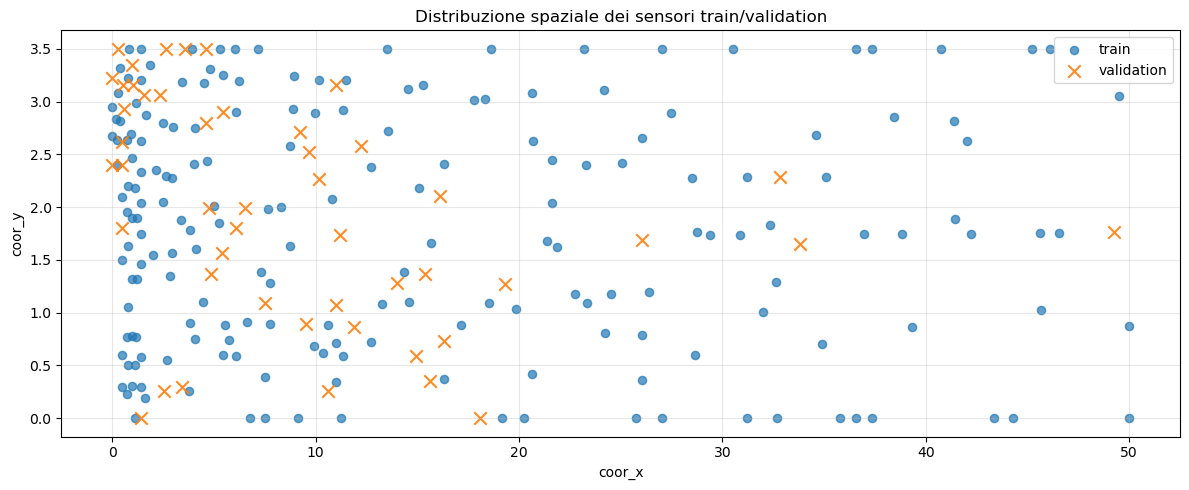

In [21]:
import matplotlib.pyplot as plt

train_sensor_pos = (
    train_df
    .groupby("sensor")[["coor_x", "coor_y"]]
    .mean()
    .reset_index()
)

val_sensor_pos = (
    val_df
    .groupby("sensor")[["coor_x", "coor_y"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))

plt.scatter(
    train_sensor_pos["coor_x"],
    train_sensor_pos["coor_y"],
    s=35,
    label="train",
    alpha=0.7
)

plt.scatter(
    val_sensor_pos["coor_x"],
    val_sensor_pos["coor_y"],
    s=80,
    label="validation",
    alpha=0.9,
    marker="x"
)

plt.xlabel("coor_x")
plt.ylabel("coor_y")
plt.title("Distribuzione spaziale dei sensori train/validation")

plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

# NON usare plt.axis("equal"), altrimenti la y viene schiacciata
plt.tight_layout()
plt.show()

## Neural Network architecture

In [22]:
class TemperatureNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            
            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)   # output lineare: temperatura normalizzata
        )

    def forward(self, x):
        return self.network(x)

## Weight initialization (Kaiming)

In [23]:
def initialize_weights(model):
    for layer in model.modules():
        if isinstance(layer, nn.Linear):
            nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")

            if layer.bias is not None:
                nn.init.zeros_(layer.bias)

## Create tensors and move to GPU

In [ ]:
# OPA tensors (used by main model)
X_train_tensor = torch.tensor(X_train_norm, dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(y_train_norm, dtype=torch.float32, device=device)
X_val_tensor   = torch.tensor(X_val_norm,   dtype=torch.float32, device=device)
y_val_tensor   = torch.tensor(y_val_norm,   dtype=torch.float32, device=device)

# Buffer tensors
X_train_buf_tensor = torch.tensor(X_train_buf, dtype=torch.float32, device=device)
y_train_buf_tensor = torch.tensor(y_train_buf, dtype=torch.float32, device=device)
X_val_buf_tensor   = torch.tensor(X_val_buf,   dtype=torch.float32, device=device)
y_val_buf_tensor   = torch.tensor(y_val_buf,   dtype=torch.float32, device=device)

## Model instantiation

In [ ]:
input_dim = X_train_tensor.shape[1]

# Model for OPA zone
model = TemperatureNN(input_dim).to(device)
initialize_weights(model)

# Model for Buffer zone
model_buf = TemperatureNN(input_dim).to(device)
initialize_weights(model_buf)

print(model)

TemperatureNN(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Loss, optimizer & regularization

In [ ]:
loss_fn = nn.HuberLoss(delta=1.0)

# OPA optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

# Buffer optimizer
optimizer_buf = torch.optim.AdamW(model_buf.parameters(), lr=1e-4, weight_decay=1e-3)

## Training loop

In [27]:
batch_size = 65536
num_epochs = 100

# Early stopping
best_val_loss = float("inf")
patience = 50
counter = 0
min_delta = 1e-5

best_model_path = "best_temperature_model.pt"

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    perm = torch.randperm(X_train_tensor.shape[0], device=device)

    train_loss_sum = 0.0

    for i in range(0, X_train_tensor.shape[0], batch_size):
        idx = perm[i:i+batch_size]
        Xb = X_train_tensor[idx]
        yb = y_train_tensor[idx]

        optimizer.zero_grad(set_to_none=True)

        pred = model(Xb)
        loss = loss_fn(pred, yb)

        loss.backward()

        # Opzionale, ma utile per evitare gradienti troppo grandi
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss_sum += loss.item() * Xb.shape[0]

    train_loss = train_loss_sum / X_train_tensor.shape[0]

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_tensor)
        val_loss = loss_fn(val_pred, y_val_tensor).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:03d} | train {train_loss:.6f} | val {val_loss:.6f}")

    # Early stopping check
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        counter += 1
        print(f"  No improvement: {counter}/{patience}")

        if counter >= patience:
            print(f"\nEarly stopping attivato alla epoch {epoch}")
            print(f"Migliore val loss: {best_val_loss:.6f}")
            break

# Ricarica il modello migliore, non quello dell'ultima epoca
model.load_state_dict(torch.load(best_model_path))

print(f"\nTraining terminato. Best val loss: {best_val_loss:.6f}")

Epoch 000 | train 0.273446 | val 0.118510
Epoch 001 | train 0.121395 | val 0.073973
Epoch 002 | train 0.095802 | val 0.059167
Epoch 003 | train 0.086840 | val 0.052061
Epoch 004 | train 0.082369 | val 0.048055
Epoch 005 | train 0.079737 | val 0.046030
Epoch 006 | train 0.077931 | val 0.044555
Epoch 007 | train 0.076553 | val 0.043678
Epoch 008 | train 0.075452 | val 0.043261
Epoch 009 | train 0.074490 | val 0.042866
Epoch 010 | train 0.073640 | val 0.042457
Epoch 011 | train 0.072925 | val 0.042363
Epoch 012 | train 0.072292 | val 0.042255
Epoch 013 | train 0.071680 | val 0.042146
Epoch 014 | train 0.071120 | val 0.042128
Epoch 015 | train 0.070593 | val 0.042085
Epoch 016 | train 0.070084 | val 0.042069
Epoch 017 | train 0.069582 | val 0.042229
  No improvement: 1/50
Epoch 018 | train 0.069080 | val 0.042146
  No improvement: 2/50
Epoch 019 | train 0.068579 | val 0.042195
  No improvement: 3/50
Epoch 020 | train 0.068075 | val 0.042184
  No improvement: 4/50
Epoch 021 | train 0.067547

In [ ]:
# Training loop — Buffer zone
print('=== Training Buffer model ===')
best_val_loss_buf = float("inf")
patience_buf = 50
counter_buf  = 0
best_model_buf_path = "best_temperature_model_buf.pt"

for epoch in range(num_epochs):
    model_buf.train()
    perm = torch.randperm(X_train_buf_tensor.shape[0], device=device)
    train_loss_sum = 0.0
    for i in range(0, X_train_buf_tensor.shape[0], batch_size):
        idx = perm[i:i+batch_size]
        Xb = X_train_buf_tensor[idx]
        yb = y_train_buf_tensor[idx]
        optimizer_buf.zero_grad(set_to_none=True)
        pred = model_buf(Xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_buf.parameters(), max_norm=1.0)
        optimizer_buf.step()
        train_loss_sum += loss.item() * Xb.shape[0]
    train_loss = train_loss_sum / X_train_buf_tensor.shape[0]
    model_buf.eval()
    with torch.no_grad():
        val_pred = model_buf(X_val_buf_tensor)
        val_loss = loss_fn(val_pred, y_val_buf_tensor).item()
    print(f"Epoch {epoch:03d} | train {train_loss:.6f} | val {val_loss:.6f}")
    if val_loss < best_val_loss_buf - min_delta:
        best_val_loss_buf = val_loss
        counter_buf = 0
        torch.save(model_buf.state_dict(), best_model_buf_path)
    else:
        counter_buf += 1
        print(f"  No improvement: {counter_buf}/{patience_buf}")
        if counter_buf >= patience_buf:
            print(f"\nEarly stopping at epoch {epoch}")
            break

model_buf.load_state_dict(torch.load(best_model_buf_path))
print(f"Buffer model best val loss: {best_val_loss_buf:.6f}")

## Evaluate on validation set

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model.eval()

with torch.no_grad():
    y_val_pred_norm = model(X_val_tensor).cpu().numpy()

y_val_true_norm = y_val_tensor.cpu().numpy()

# Torno alla scala originale in °C
y_val_pred = scaler_y.inverse_transform(y_val_pred_norm)
y_val_true = scaler_y.inverse_transform(y_val_true_norm)

mae = mean_absolute_error(y_val_true, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
r2 = r2_score(y_val_true, y_val_pred)

print(f"Validation MAE:  {mae:.4f} °C")
print(f"Validation RMSE: {rmse:.4f} °C")
print(f"Validation R2:   {r2:.4f}")

Validation MAE:  2.5360 °C
Validation RMSE: 4.4656 °C
Validation R2:   0.9024


## Compare with baseline

In [29]:
baseline_pred = np.full_like(y_val, y_train.mean())

baseline_mae = mean_absolute_error(y_val, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_val, baseline_pred))

print(f"Baseline MAE:  {baseline_mae:.4f} °C")
print(f"Baseline RMSE: {baseline_rmse:.4f} °C")

Baseline MAE:  10.7390 °C
Baseline RMSE: 14.2932 °C


## Error analysis by sensor

In [30]:
val_results = val_df.copy()
val_results["y_true"] = y_val_true.ravel()
val_results["y_pred"] = y_val_pred.ravel()
val_results["abs_error"] = np.abs(val_results["y_true"] - val_results["y_pred"])
val_results["sq_error"] = (val_results["y_true"] - val_results["y_pred"]) ** 2

sensor_metrics = (
    val_results
    .groupby("sensor")
    .agg(
        mae=("abs_error", "mean"),
        rmse=("sq_error", lambda x: np.sqrt(np.mean(x))),
        coor_x=("coor_x", "first"),
        coor_y=("coor_y", "first"),
        true_mean=("y_true", "mean"),
        pred_mean=("y_pred", "mean")
    )
    .sort_values("mae", ascending=False)
)

print(sensor_metrics.head(20))

              mae       rmse     coor_x    coor_y  true_mean  pred_mean
sensor                                                                 
N749    15.191627  17.774481  15.646701  0.356862  37.114464  22.200552
N862    10.646759  12.744464   6.525898  1.996336  13.163382  23.592775
N4       3.694979   5.337667   1.400000  0.000000  29.342382  26.984598
N201     3.602593   4.951508   0.500000  1.800000  25.115898  26.853680
N5       3.453718   5.003621   0.500000  2.400000  24.949896  25.040291
N6       3.147080   5.085966   0.000000  2.400000  25.041239  25.204002
N185     3.050415   4.517392   0.280000  3.500000  30.102772  28.134352
N236     2.984030   4.017777  26.063416  1.689136  19.286606  22.046083
N245     2.981980   3.905618  11.024173  1.068612  22.244886  24.726309
N269     2.800898   3.222797  11.873100  0.864290  22.000544  24.227030
N419     2.774259   3.309449  14.009471  1.282171  21.437159  23.754009
N681     2.594170   3.492873  15.379160  1.365870  21.130920  23

## Plot predictions vs true values

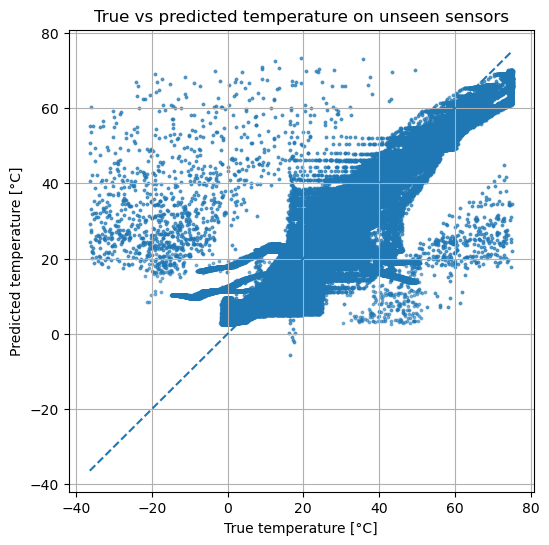

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_val_true, y_val_pred, s=3, alpha=0.3)

min_val = min(y_val_true.min(), y_val_pred.min())
max_val = max(y_val_true.max(), y_val_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("True temperature [°C]")
plt.ylabel("Predicted temperature [°C]")
plt.title("True vs predicted temperature on unseen sensors")
plt.grid(True)
plt.show()

## Error analysis over time

In [32]:
# Trova i valori del training predetti
model.eval()

with torch.no_grad():
    X_train_tensor = torch.tensor(X_train_norm, dtype=torch.float32).to(device)

    y_train_pred_norm = model(X_train_tensor).cpu().numpy()

# Riporto le predizioni dalla scala normalizzata alla scala originale
y_train_pred = scaler_y.inverse_transform(y_train_pred_norm)

train_results = train_df.copy()
train_results["temperature_true"] = y_train.ravel()
train_results["temperature_pred"] = y_train_pred.ravel()
train_results["abs_error"] = np.abs(
    train_results["temperature_true"] - train_results["temperature_pred"]
)

# Converto il tempo da secondi ad anni
train_results["time_years"] = train_results["time"] / (365.25 * 24 * 3600)
val_results["time_years"] = val_results["time"] / (365.25 * 24 * 3600)

# Uso gli stessi bin temporali per train e validation,
# così il confronto è fatto sugli stessi intervalli di tempo
all_time_years = pd.concat([
    train_results["time_years"],
    val_results["time_years"]
])

time_bins = pd.qcut(
    all_time_years,
    q=20,
    duplicates="drop"
).cat.categories

# MAE nel tempo sul training set
train_time_error = (
    train_results
    .groupby(pd.cut(train_results["time_years"], bins=time_bins, include_lowest=True), observed=False)
    .agg(train_mae=("abs_error", "mean"))
    .reset_index()
)

# MAE nel tempo sul validation set
val_time_error = (
    val_results
    .groupby(pd.cut(val_results["time_years"], bins=time_bins, include_lowest=True), observed=False)
    .agg(val_mae=("abs_error", "mean"))
    .reset_index()
)

# Punto centrale di ogni intervallo temporale
train_time_error["time_mid"] = train_time_error["time_years"].apply(lambda x: x.mid)
val_time_error["time_mid"] = val_time_error["time_years"].apply(lambda x: x.mid)

print("Training MAE over time:")
print(train_time_error)

print("\nValidation MAE over time:")
print(val_time_error)

Training MAE over time:
            time_years  train_mae  time_mid
0     (-0.001, 10.979]   2.339950    5.4890
1     (10.979, 21.793]   1.861320   16.3860
2     (21.793, 32.638]   2.242828   27.2155
3     (32.638, 43.452]   2.360364   38.0450
4      (43.452, 54.27]   2.160850   48.8610
5      (54.27, 65.166]   2.446085   59.7180
6     (65.166, 76.148]   2.439357   70.6570
7     (76.148, 87.154]   2.493608   81.6510
8     (87.154, 98.051]   2.677476   92.6025
9    (98.051, 108.813]   3.498572  103.4320
10    (108.813, 119.6]   3.034976  114.2065
11    (119.6, 130.335]   3.343577  124.9675
12   (130.335, 141.15]   3.131088  135.7425
13   (141.15, 152.433]   3.586515  146.7915
14  (152.433, 168.613]   3.996913  160.5230
15  (168.613, 184.797]   3.637451  176.7050
16  (184.797, 200.925]   3.753153  192.8610
17  (200.925, 217.133]   3.885064  209.0290
18  (217.133, 233.399]   4.011750  225.2660
19  (233.399, 249.829]   3.942727  241.6140

Validation MAE over time:
            time_years   

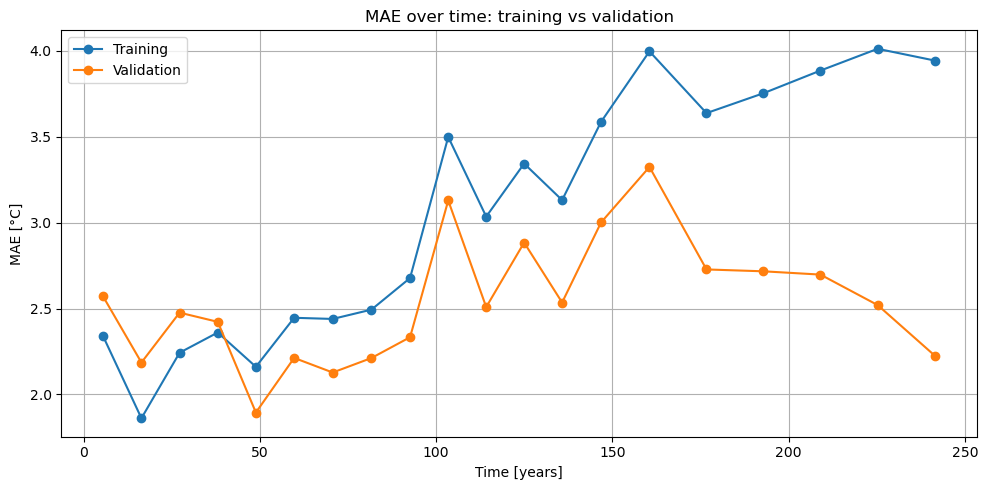

In [33]:
# Plot comparativo
plt.figure(figsize=(10, 5))

plt.plot(
    train_time_error["time_mid"],
    train_time_error["train_mae"],
    marker="o",
    label="Training"
)

plt.plot(
    val_time_error["time_mid"],
    val_time_error["val_mae"],
    marker="o",
    label="Validation"
)

plt.xlabel("Time [years]")
plt.ylabel("MAE [°C]")
plt.title("MAE over time: training vs validation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Final predictions & submission file

In [ ]:
# ============================================================
# Final predictions & submission
# ============================================================

# Recharger test proprement
test = pd.read_parquet("test.parquet")
sensors_df = pd.read_parquet("sensors.parquet")
sensors_df = sensors_df.drop_duplicates(subset='sensor', keep='first')

# Merge
test_full = test.merge(sensors_df, on='sensor', how='left')

# Cumulative energy — calculer sans dupliquer les lignes
power_time = (
    test_full[['time', 'power']]
    .drop_duplicates(subset=['time'])  # ← garder un seul time
    .sort_values('time')
    .copy()
)
power_time['dt']         = power_time['time'].diff().fillna(0)
power_time['cum_energy'] = (power_time['power'] * power_time['dt']).cumsum()

# Merge sur time uniquement après déduplication
test_full = test_full.merge(
    power_time[['time', 'cum_energy']].drop_duplicates(subset=['time']),
    on='time', how='left'
)

print(f'len(test)      : {len(test)}')
print(f'len(test_full) : {len(test_full)}')

# Keep raw time, consistent with training data

# Add engineered features also on test set
eps = 1e-8

test_full["dist2"] = test_full["coor_x"]**2 + test_full["coor_y"]**2
test_full["power_over_dist2"] = test_full["power"] / (test_full["dist2"] + eps)
test_full["diffusion"] = test_full["dist2"] / (test_full["time"] + eps)

print(f'len(test)      : {len(test)}')
print(f'len(test_full) : {len(test_full)}')

print(f'len(test)      : {len(test)}')
print(f'len(test_full) : {len(test_full)}')

# Prepare features
# Split test par zone
test_buffer_df = test_full[test_full["coor_x"] < 1.4].copy()
test_opa_df    = test_full[test_full["coor_x"] >= 1.4].copy()

# OPA predictions
X_test_opa   = scaler_X_opa.transform(test_opa_df[feature_cols].values)
X_test_opa_t = torch.tensor(X_test_opa, dtype=torch.float32, device=device)
model.eval()
with torch.no_grad():
    y_pred_opa = scaler_y_opa.inverse_transform(model(X_test_opa_t).cpu().numpy()).ravel()

# Buffer predictions
X_test_buf   = scaler_X_buf.transform(test_buffer_df[feature_cols].values)
X_test_buf_t = torch.tensor(X_test_buf, dtype=torch.float32, device=device)
model_buf.eval()
with torch.no_grad():
    y_pred_buf = scaler_y_buf.inverse_transform(model_buf(X_test_buf_t).cpu().numpy()).ravel()

# Recombine in original order
test_full["temperature_pred"] = np.nan
test_full.loc[test_full["coor_x"] >= 1.4, "temperature_pred"] = y_pred_opa
test_full.loc[test_full["coor_x"] <  1.4, "temperature_pred"] = y_pred_buf
y_test_pred = test_full["temperature_pred"].values

print(f'len(y_test_pred) : {len(y_test_pred)}')

# Submission
submission = pd.DataFrame({
    'Id': np.arange(len(test), dtype=int),
    'temperature': y_test_pred.astype(float)
})

assert list(submission.columns) == ['Id', 'temperature']
assert len(submission) == len(test)
assert np.isfinite(submission['temperature']).all()
assert submission.isna().sum().sum() == 0

submission.to_csv('submission.csv', index=False)
print(f'submission.csv saved — {len(submission)} rows')
display(submission.head())

len(test)      : 2190480
len(test_full) : 2190480
len(test)      : 2190480
len(test_full) : 2190480
len(test)      : 2190480
len(test_full) : 2190480
len(y_test_pred) : 2190480
submission.csv saved — 2190480 rows


,Id,temperature
0,0,17.232470
1,1,17.233383
2,2,17.234310
3,3,17.235226
4,4,17.236143
